In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import contextily as ctx
import folium

from viz.geo import show_nearest_stations

In [2]:
gdf = gpd.read_file("../data/geo-stations.geojson")

In [3]:
oan_gems_s = gpd.read_file("../data/oan_gems_seleccion.geojson")

In [4]:
gdf.head()

,name,wigos_station_identifier,traditional_station_identifier,barometer_height,facility_type,territory_name,wmo_region,url,topic,topics,status,id,geometry
0,Paso de los Toros,0-20000-0-86460,86460,76.38,landFixed,URY,southAmerica,https://oscar.wmo.int/surface/#/search/station...,origin/a/wis2/uy-inumet/data/core/weather/surf...,[origin/a/wis2/uy-inumet/data/core/weather/sur...,operational,0-20000-0-86460,POINT Z (-56.5147 -32.7967 80.97)
1,Laguna del Sauce,0-20000-0-86586,86586,34.00,landFixed,URY,southAmerica,https://oscar.wmo.int/surface/#/search/station...,origin/a/wis2/uy-inumet/data/core/weather/surf...,[origin/a/wis2/uy-inumet/data/core/weather/sur...,operational,0-20000-0-86586,POINT Z (-55.1071 -34.8604 28.33)
2,Paysandu,0-20000-0-86430,86430,61.12,landFixed,URY,southAmerica,https://oscar.wmo.int/surface/#/search/station...,origin/a/wis2/uy-inumet/data/core/weather/surf...,[origin/a/wis2/uy-inumet/data/core/weather/sur...,operational,0-20000-0-86430,POINT Z (-58.0312 -32.381 61.12)
3,Rocha,0-20000-0-86565,86565,19.10,landFixed,URY,southAmerica,https://oscar.wmo.int/surface/#/search/station...,origin/a/wis2/uy-inumet/data/core/weather/surf...,[origin/a/wis2/uy-inumet/data/core/weather/sur...,operational,0-20000-0-86565,POINT Z (-54.3125 -34.4936 18.16)
4,Salto,0-20000-0-86360,86360,42.20,landFixed,URY,southAmerica,https://oscar.wmo.int/surface/#/search/station...,origin/a/wis2/uy-inumet/data/core/weather/surf...,[origin/a/wis2/uy-inumet/data/core/weather/sur...,operational,0-20000-0-86360,POINT Z (-57.981 -31.4388 39.59)


In [5]:
gdf = gdf.drop(columns=["wigos_station_identifier", "traditional_station_identifier", "barometer_height", "facility_type",  "territory_name", "wmo_region", "url", "topic", "topics", "status"])
gdf

,name,id,geometry
0,Paso de los Toros,0-20000-0-86460,POINT Z (-56.5147 -32.7967 80.97)
1,Laguna del Sauce,0-20000-0-86586,POINT Z (-55.1071 -34.8604 28.33)
2,Paysandu,0-20000-0-86430,POINT Z (-58.0312 -32.381 61.12)
3,Rocha,0-20000-0-86565,POINT Z (-54.3125 -34.4936 18.16)
4,Salto,0-20000-0-86360,POINT Z (-57.981 -31.4388 39.59)
5,Prado,0-20000-0-86585,POINT Z (-56.20739 -34.86064 16.27)
6,San Jacinto,0-858-0-A000000000000002,POINT Z (-55.8464 -34.5145 74.42)
7,Punta del Este,0-858-0-86595,POINT Z (-54.9512 -34.9689 16.4)
8,San Jose,0-858-0-86550,POINT Z (-56.7497 -34.3519 72)
9,Carrasco,0-20000-0-86580,POINT Z (-56.01288 -34.83292 32.88)


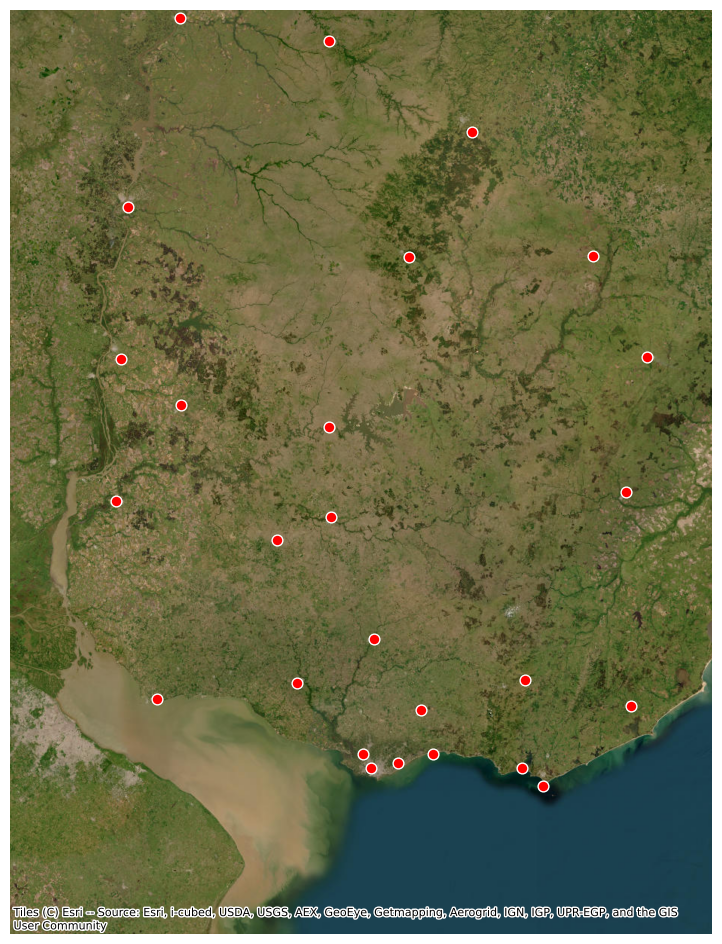

In [6]:
ax = gdf.to_crs(3857).plot(figsize=(10, 12), markersize=60, color='red', edgecolor='white')

ax.set_xlim(-6.55e6, -5.98e6)
ax.set_ylim(-4.28e6, -3.53e6)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=8)
ax.set_axis_off()

In [7]:

oan_gems_s.head(5)

,fecha,Decision,value,unit,fuente,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado,chla,grupo_nombre,geometry
0,2017-01-02,NaN,NaN,NaN,OAN,8.900,0.100,0.1,8.900,8.900,RDP-MONTES,POINT (401164.986 6214585.025)
1,2017-01-02,si,0.0068,mg/l,GEMS,NaN,NaN,NaN,NaN,6.800000090152,LDS,POINT (678380.002 6147956.963)
2,2017-01-02,si,0.0032,mg/l,GEMS,NaN,NaN,NaN,NaN,3.1999999191612,LDS,POINT (679045.962 6144090.994)
3,2017-01-02,NaN,NaN,NaN,OAN,4.400,0.100,0.1,4.400,4.400,RDP-MONTES,POINT (402233.023 6210401.038)
4,2017-01-02,NaN,NaN,NaN,OAN,5.900,0.100,0.1,5.900,5.900,RDP-MONTES,POINT (401555.004 6213022.975)


In [8]:
gdf["geometry"] = gdf.geometry.force_2d()
gdf

,name,id,geometry
0,Paso de los Toros,0-20000-0-86460,POINT (-56.5147 -32.7967)
1,Laguna del Sauce,0-20000-0-86586,POINT (-55.1071 -34.8604)
2,Paysandu,0-20000-0-86430,POINT (-58.0312 -32.381)
3,Rocha,0-20000-0-86565,POINT (-54.3125 -34.4936)
4,Salto,0-20000-0-86360,POINT (-57.981 -31.4388)
5,Prado,0-20000-0-86585,POINT (-56.20739 -34.86064)
6,San Jacinto,0-858-0-A000000000000002,POINT (-55.8464 -34.5145)
7,Punta del Este,0-858-0-86595,POINT (-54.9512 -34.9689)
8,San Jose,0-858-0-86550,POINT (-56.7497 -34.3519)
9,Carrasco,0-20000-0-86580,POINT (-56.01288 -34.83292)


In [9]:
gdf = gdf.to_crs(oan_gems_s.crs)

In [10]:
grouped_gdf = oan_gems_s.dissolve(by="grupo_nombre") # el equivalente a groupby pero para geo
centroides = grouped_gdf.geometry.centroid
centroides

grupo_nombre
LDS           POINT (675535.851 6147158.613)
RDP-MONTES    POINT (398802.781 6213894.226)
RN-UPM1       POINT (381975.619 6335058.369)
RN-UPM2       POINT (538577.614 6366560.152)
dtype: geometry

In [11]:
indices_mas_cercanas = []
for nombre, punto in centroides.items():
    # dist(estaction, punto) (para N estaciones)
    dist_estaciones = gdf.distance(punto)
    mas_cercana = dist_estaciones.min()
    index = dist_estaciones.argmin()
    print(mas_cercana, nombre)
    indices_mas_cercanas.append(index)



6829.546936280534 LDS
40460.98460480424 RDP-MONTES
23531.42930592721 RN-UPM1
8252.647125135807 RN-UPM2


In [12]:
gdf.iloc[1] # LDS 

name                                   Laguna del Sauce
id                                      0-20000-0-86586
geometry    POINT (673034.1032419999 6140803.774578484)
Name: 1, dtype: object

In [13]:
gdf.iloc[10] # RN-UPM1 

name                                           Mercedes
id                                      0-20000-0-86490
geometry    POINT (400400.7815732522 6320421.376719408)
Name: 10, dtype: object

In [14]:
gdf.iloc[11] # RDP-MONTES  

name                                            Colonia
id                                      0-20000-0-86560
geometry    POINT (429449.9651013682 6187477.538533542)
Name: 11, dtype: object

In [15]:
gdf.iloc[0] # RN-UPM2 

name                                  Paso de los Toros
id                                      0-20000-0-86460
geometry    POINT (545438.6146020428 6371146.310775591)
Name: 0, dtype: object

In [16]:
gdf_estaciones_inumet = gdf.iloc[indices_mas_cercanas]
gdf_estaciones_inumet 

,name,id,geometry
1,Laguna del Sauce,0-20000-0-86586,POINT (673034.103 6140803.775)
11,Colonia,0-20000-0-86560,POINT (429449.965 6187477.539)
10,Mercedes,0-20000-0-86490,POINT (400400.782 6320421.377)
0,Paso de los Toros,0-20000-0-86460,POINT (545438.615 6371146.311)


In [17]:
dict(zip(centroides.index, gdf_estaciones_inumet["name"].values))

{'LDS': 'Laguna del Sauce',
 'RDP-MONTES': 'Colonia',
 'RN-UPM1': 'Mercedes',
 'RN-UPM2': 'Paso de los Toros'}

In [19]:
show_nearest_stations(centroides, gdf)